In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 1. Load Dataset

In [2]:
DATA_PATH = "/kaggle/input/datasets/rishab023/final-load-dataset/loan_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))


Shape: (100000, 57)
Rows: 100000
Columns: 57


In [3]:
df.head()

,customer_id,age,gender,marital_status,dependents,education_level,employment_type,employment_years,residence_type,city_tier,...,cash_withdrawal_frequency,digital_payment_ratio,salary_delay_days_avg,default_status,default_probability,risk_category,anomaly_flag,anomaly_type,fraud_risk_score,data_quality_flag
0,CUST0000001,48,Female,Married,1,PhD,Salaried,19.8,Family Owned,Tier 2,...,5,0.4280,1.2,0,0.0342,Low,0,none,7.3,0
1,CUST0000002,24,Female,Single,0,PhD,Contract,1.1,Owned,Tier 2,...,8,0.5950,0.5,1,0.1891,Low,0,none,4.1,0
2,CUST0000003,43,Female,Married,4,Bachelor,Salaried,15.8,Owned,Tier 2,...,4,0.5943,0.2,0,0.0070,Low,0,none,30.7,0
3,CUST0000004,38,Male,Married,1,Bachelor,Salaried,11.9,Mortgaged,Tier 1,...,6,0.6117,1.9,1,0.5894,High,0,none,8.2,0
4,CUST0000005,61,Male,Single,0,Bachelor,Retired,28.4,Rented,Tier 2,...,11,0.1276,0.7,0,0.0634,Low,0,none,5.9,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    100000 non-null  object 
 1   age                            100000 non-null  int64  
 2   gender                         99997 non-null   object 
 3   marital_status                 99928 non-null   object 
 4   dependents                     100000 non-null  int64  
 5   education_level                99936 non-null   object 
 6   employment_type                99991 non-null   object 
 7   employment_years               99931 non-null   float64
 8   residence_type                 99943 non-null   object 
 9   city_tier                      99999 non-null   object 
 10  annual_income                  99931 non-null   float64
 11  monthly_income                 100000 non-null  float64
 12  monthly_expenses               

In [5]:
df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'marital_status',
 'dependents',
 'education_level',
 'employment_type',
 'employment_years',
 'residence_type',
 'city_tier',
 'annual_income',
 'monthly_income',
 'monthly_expenses',
 'existing_loan_count',
 'existing_loan_amount',
 'monthly_existing_emi',
 'credit_card_count',
 'credit_card_utilization',
 'savings_balance',
 'investment_balance',
 'debt_to_income_ratio',
 'net_monthly_cash_flow',
 'credit_score',
 'credit_history_years',
 'previous_loan_count',
 'previous_defaults',
 'previous_loan_repayment_ratio',
 'missed_payment_count_12m',
 'days_past_due_max',
 'recent_credit_inquiries',
 'credit_utilization_ratio',
 'loan_id',
 'loan_type',
 'loan_amount',
 'loan_term_months',
 'interest_rate',
 'monthly_emi',
 'loan_to_income_ratio',
 'collateral_value',
 'collateral_type',
 'application_channel',
 'loan_purpose',
 'account_age_months',
 'avg_monthly_transaction_count',
 'avg_monthly_transaction_value',
 'income_stability_score',
 'spendin

## 2. Data Quality Checks

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())
print("Duplicate loan IDs:", df["loan_id"].duplicated().sum())


Duplicate rows: 0
Duplicate customer IDs: 0
Duplicate loan IDs: 0


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


previous_loan_repayment_ratio    22841
savings_balance                     80
credit_history_years                76
avg_monthly_transaction_count       75
marital_status                      72
employment_years                    69
annual_income                       69
income_stability_score              66
monthly_expenses                    64
education_level                     64
salary_delay_days_avg               61
credit_score                        61
residence_type                      57
employment_type                      9
gender                               3
loan_type                            3
loan_purpose                         2
collateral_type                      1
application_channel                  1
city_tier                            1
dtype: int64

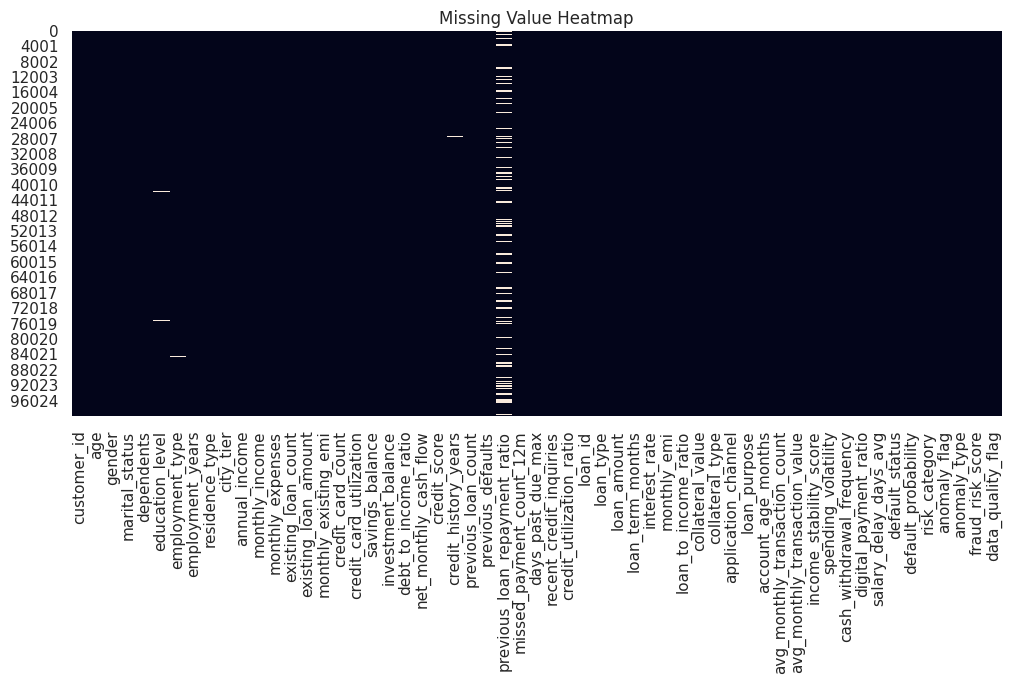

In [8]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


## 3. Target and Anomaly Analysis

In [9]:
print("Default counts:")
print(df["default_status"].value_counts())
print("\nDefault percentage:")
print((df["default_status"].value_counts(normalize=True) * 100).round(2))


Default counts:
default_status
0    80793
1    19207
Name: count, dtype: int64

Default percentage:
default_status
0    80.79
1    19.21
Name: proportion, dtype: float64


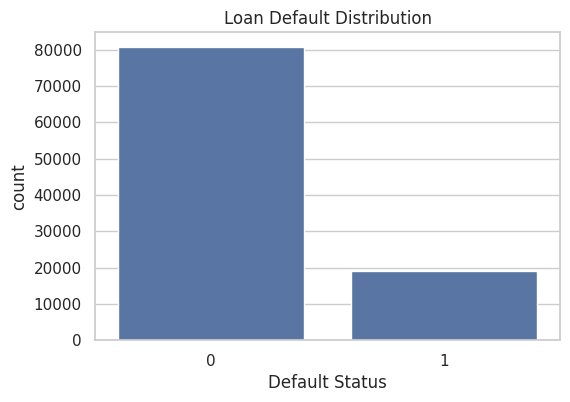

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="default_status")
plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.show()


In [11]:
print(df["anomaly_type"].value_counts())
print("\nAnomaly percentage:")
print((df["anomaly_flag"].value_counts(normalize=True) * 100).round(2))


anomaly_type
none                       96250
income_mismatch              450
credit_score_outlier         400
loan_income_mismatch         400
duplicate_pattern            400
employment_age_mismatch      350
fraud_pattern                300
transaction_outlier          300
emi_income_mismatch          300
negative_value               250
behavioral_outlier           250
multiple_anomalies           200
invalid_category             150
Name: count, dtype: int64

Anomaly percentage:
anomaly_flag
0    96.25
1     3.75
Name: proportion, dtype: float64


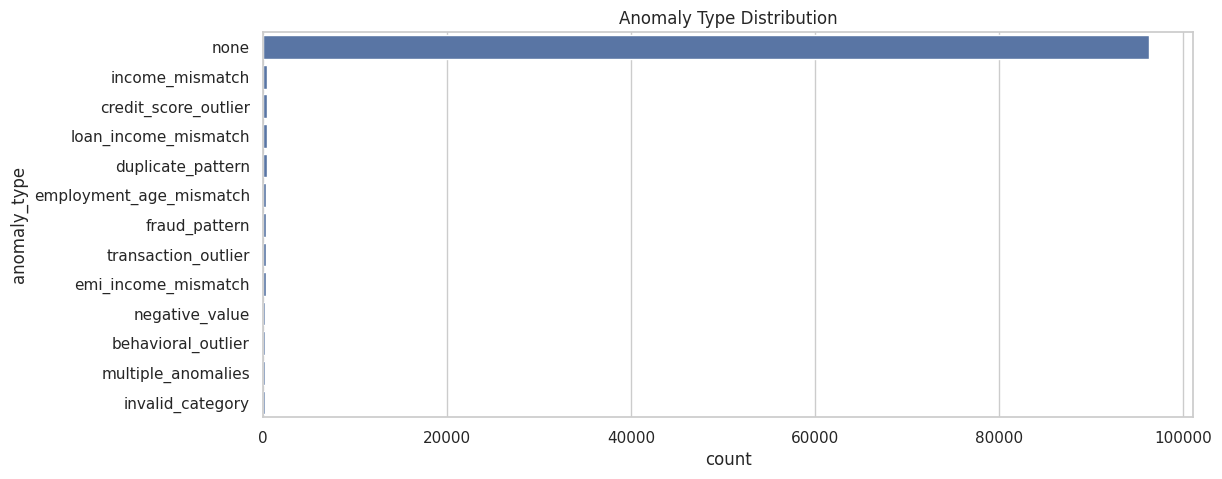

In [12]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y="anomaly_type",
              order=df["anomaly_type"].value_counts().index)
plt.title("Anomaly Type Distribution")
plt.show()


## 4. Exploratory Data Analysis

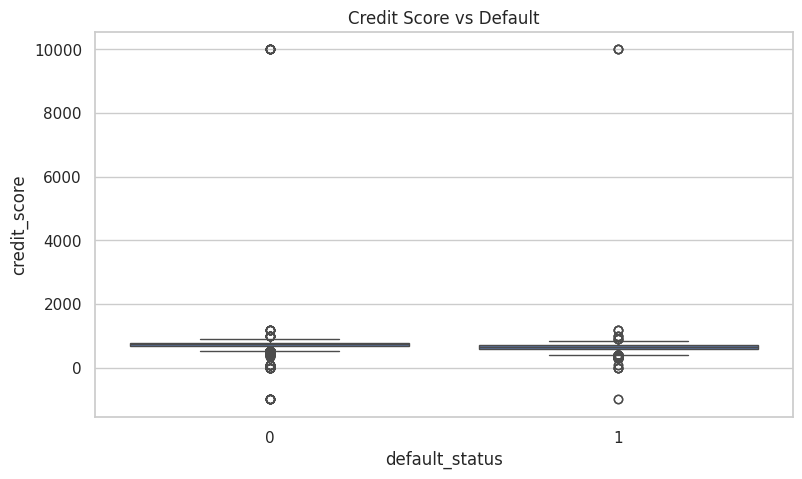

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="default_status", y="credit_score")
plt.title("Credit Score vs Default")
plt.show()


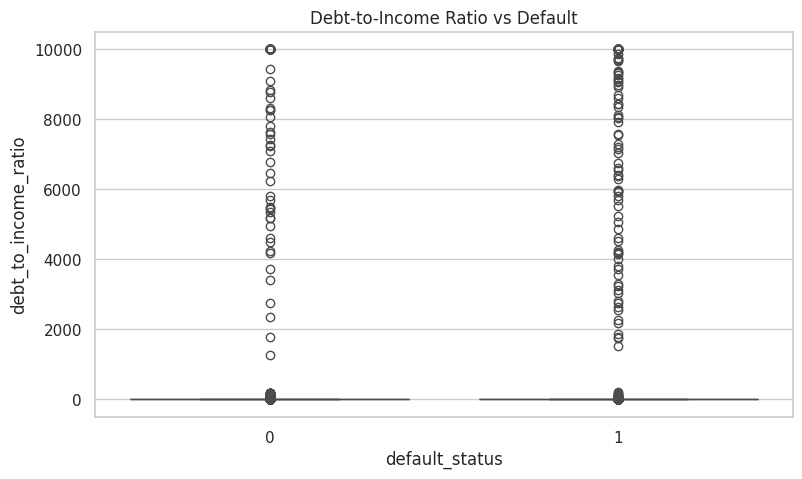

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="default_status", y="debt_to_income_ratio")
plt.title("Debt-to-Income Ratio vs Default")
plt.show()


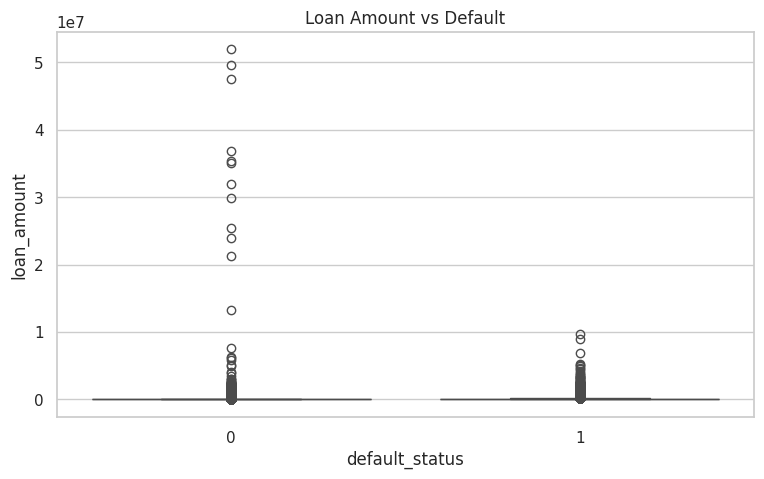

In [15]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="default_status", y="loan_amount")
plt.title("Loan Amount vs Default")
plt.show()


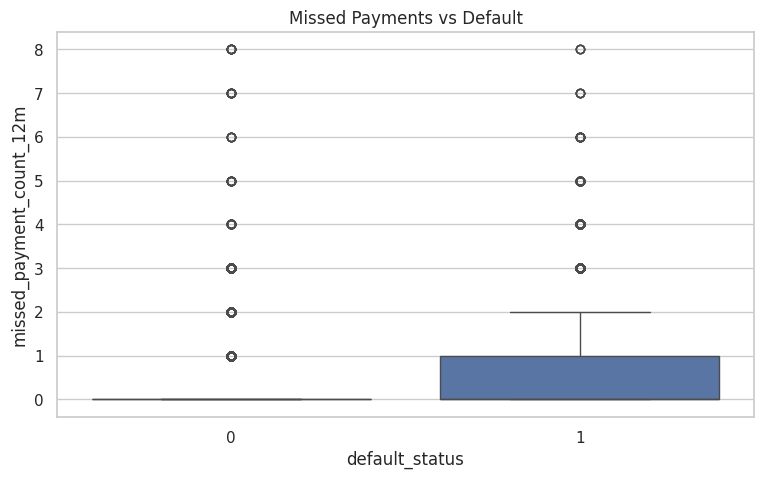

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="default_status", y="missed_payment_count_12m")
plt.title("Missed Payments vs Default")
plt.show()


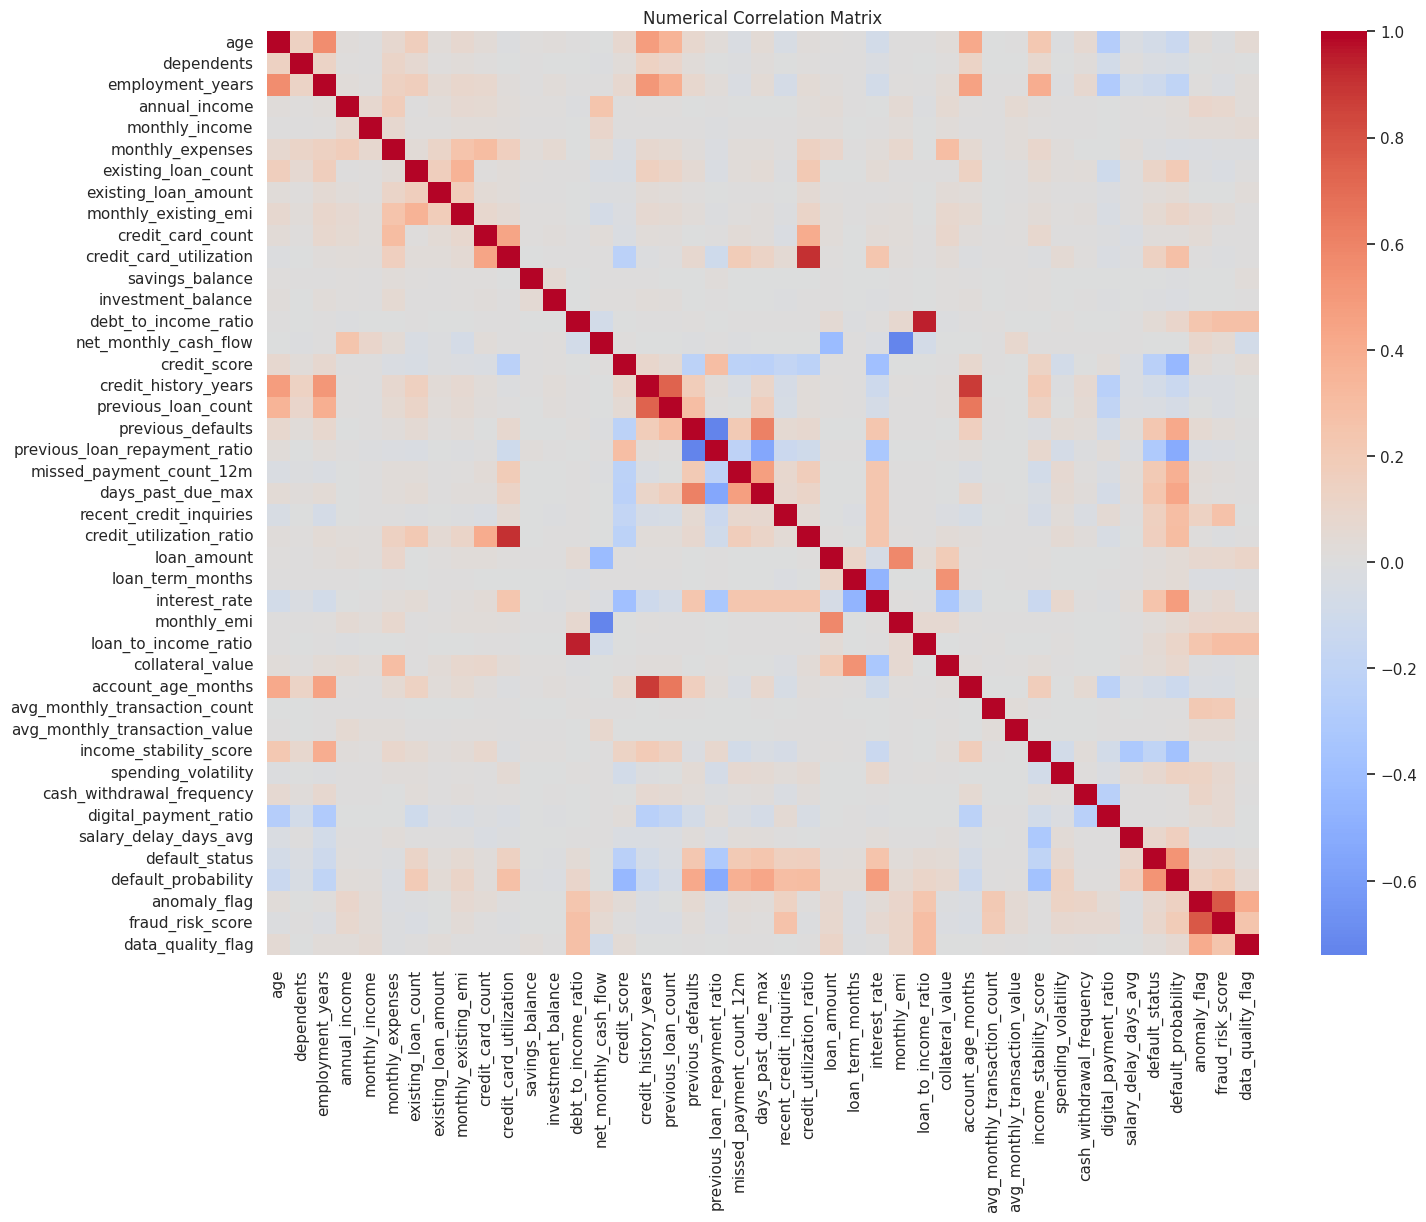

In [17]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, center=0, cmap="coolwarm")
plt.title("Numerical Correlation Matrix")
plt.show()


In [18]:
corr["default_status"].sort_values(ascending=False).head(15)


default_status              1.000000
default_probability         0.528088
interest_rate               0.255353
days_past_due_max           0.234454
previous_defaults           0.227072
missed_payment_count_12m    0.206080
credit_utilization_ratio    0.163409
recent_credit_inquiries     0.156527
credit_card_utilization     0.147038
existing_loan_count         0.112447
salary_delay_days_avg       0.090980
fraud_risk_score            0.090524
anomaly_flag                0.072787
spending_volatility         0.069105
monthly_existing_emi        0.060594
Name: default_status, dtype: float64

## 5. Feature Engineering

In [19]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # EMI-to-income ratio
    if "monthly_emi" in out.columns:
        emi = out["monthly_emi"]
    elif "emi" in out.columns:
        emi = out["emi"]
    else:
        emi = pd.Series(np.nan, index=out.index)

    if "monthly_income" in out.columns:
        monthly_income = out["monthly_income"].replace(0, np.nan)
    elif "annual_income" in out.columns:
        monthly_income = (out["annual_income"] / 12).replace(0, np.nan)
    else:
        monthly_income = pd.Series(np.nan, index=out.index)

    out["emi_income_ratio"] = emi / monthly_income

    # Loan-to-annual-income ratio
    if "loan_amount" in out.columns and "annual_income" in out.columns:
        out["loan_income_ratio"] = (
            out["loan_amount"] / out["annual_income"].replace(0, np.nan)
        )
    else:
        out["loan_income_ratio"] = np.nan

    # Total monthly debt burden relative to income
    existing_emi = (
        out["monthly_existing_emi"]
        if "monthly_existing_emi" in out.columns
        else 0
    )
    out["total_debt_burden"] = (existing_emi + emi) / monthly_income

    # Savings expressed as months of expenses
    if "savings_balance" in out.columns and "monthly_expenses" in out.columns:
        out["financial_buffer"] = (
            out["savings_balance"] /
            out["monthly_expenses"].replace(0, np.nan)
        )
    else:
        out["financial_buffer"] = np.nan

    # Age group
    if "age" in out.columns:
        out["age_group"] = pd.cut(
            out["age"],
            bins=[18, 25, 35, 45, 55, 100],
            labels=["18-25", "26-35", "36-45", "46-55", "56+"],
            include_lowest=True
        ).astype("object")
    else:
        out["age_group"] = np.nan

    return out


In [20]:
df_model = engineer_features(df)

print("Original columns:", len(df.columns))
print("After feature engineering:", len(df_model.columns))

df_model[[
    "emi_income_ratio",
    "loan_income_ratio",
    "total_debt_burden",
    "financial_buffer",
    "age_group"
]].head()


Original columns: 57
After feature engineering: 62


,emi_income_ratio,loan_income_ratio,total_debt_burden,financial_buffer,age_group
0,0.119387,0.436306,0.589500,69.226614,46-55
1,0.082294,0.181319,0.082294,4.229700,18-25
2,0.190975,0.530655,0.190975,33.953836,36-45
3,0.159695,0.403289,0.743554,2.629869,36-45
4,0.291303,2.366397,0.333497,6.760591,56+


## 6. Prepare Default-Prediction Data

In [21]:
LEAKAGE_COLUMNS = [
    "customer_id",
    "loan_id",
    "default_status",
    "default_probability",
    "risk_category",
    "anomaly_flag",
    "anomaly_type",
    "fraud_risk_score",
    "data_quality_flag"
]

X = df_model.drop(
    columns=[c for c in LEAKAGE_COLUMNS if c in df_model.columns],
    errors="ignore"
)
y = df_model["default_status"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


X shape: (100000, 53)
y shape: (100000,)
Numeric features: 42
Categorical features: 11


## 7. Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (80000, 53)
Testing: (20000, 53)


## 8. Preprocessing

In [23]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 9. Baseline Model — Logistic Regression

In [24]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, logistic_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_prob), 4))


              precision    recall  f1-score   support

           0       0.92      0.76      0.83     16159
           1       0.42      0.73      0.53      3841

    accuracy                           0.75     20000
   macro avg       0.67      0.74      0.68     20000
weighted avg       0.83      0.75      0.78     20000

ROC-AUC: 0.8263


## 10. Final Model — Random Forest Default Prediction

In [25]:
default_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

default_model.fit(X_train, y_train)

y_pred = default_model.predict(X_test)
y_prob = default_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     16159
           1       0.54      0.57      0.55      3841

    accuracy                           0.82     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.83      0.82      0.82     20000

ROC-AUC: 0.8307


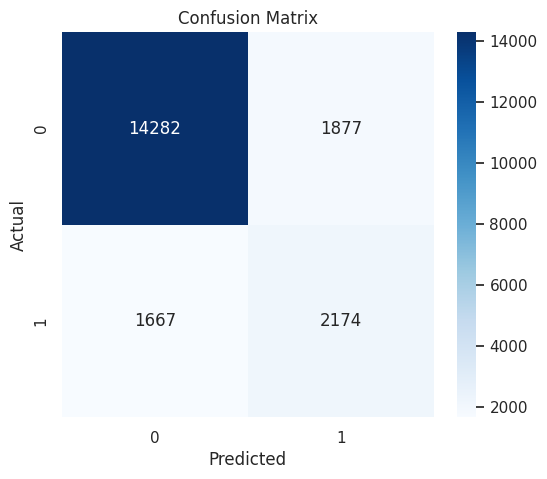

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


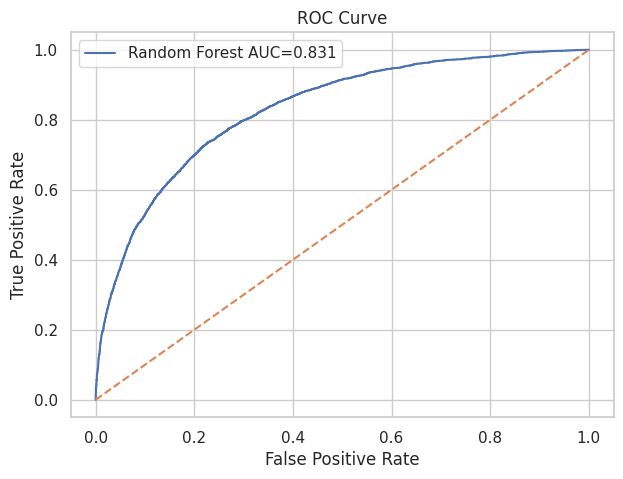

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest AUC={roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


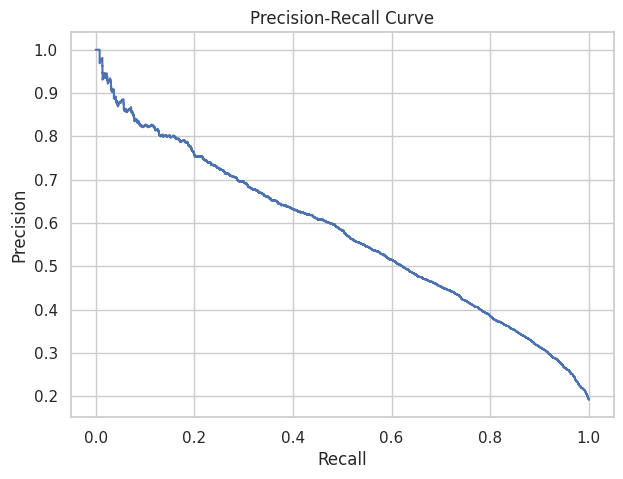

In [28]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


## 11. Cross-Validation

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    default_model,
    X, y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV scores:", cv_scores)
print("Mean CV ROC-AUC:", round(cv_scores.mean(), 4))


CV scores: [0.82254333 0.83095604 0.82258495 0.83349276 0.8303655 ]
Mean CV ROC-AUC: 0.828


## 12. Anomaly Detection — Isolation Forest

In [30]:
ANOMALY_EXCLUDE = [
    "customer_id",
    "loan_id",
    "default_status",
    "default_probability",
    "risk_category",
    "anomaly_flag",
    "anomaly_type",
    "fraud_risk_score",
    "data_quality_flag"
]

X_anomaly = df_model.drop(
    columns=[c for c in ANOMALY_EXCLUDE if c in df_model.columns],
    errors="ignore"
)

anomaly_numeric = X_anomaly.select_dtypes(include=np.number).columns.tolist()
anomaly_categorical = X_anomaly.select_dtypes(
    include=["object", "category"]
).columns.tolist()

anomaly_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), anomaly_numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), anomaly_categorical)
])

X_anomaly_processed = anomaly_preprocessor.fit_transform(X_anomaly)

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.0375,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

isolation_forest.fit(X_anomaly_processed)

anomaly_predictions = isolation_forest.predict(X_anomaly_processed)
anomaly_flags = (anomaly_predictions == -1).astype(int)
anomaly_scores = isolation_forest.decision_function(X_anomaly_processed)

print("Detected anomalies:", anomaly_flags.sum())
print("Detected anomaly percentage:", round(anomaly_flags.mean() * 100, 2), "%")


Detected anomalies: 3750
Detected anomaly percentage: 3.75 %


In [31]:
pd.crosstab(
    df_model["anomaly_flag"],
    anomaly_flags,
    rownames=["Synthetic anomaly label"],
    colnames=["Isolation Forest"]
)


Isolation Forest,0,1
Synthetic anomaly label,,
0,93050,3200
1,3200,550


## 13. Feature Importance

In [32]:
rf_classifier = default_model.named_steps["classifier"]
feature_names = default_model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)


,feature,importance
15,num__credit_score,0.126172
26,num__interest_rate,0.057232
19,num__previous_loan_repayment_ratio,0.043768
13,num__debt_to_income_ratio,0.042895
40,num__total_debt_burden,0.036979
21,num__days_past_due_max,0.036505
33,num__income_stability_score,0.035805
14,num__net_monthly_cash_flow,0.034757
41,num__financial_buffer,0.031014
11,num__savings_balance,0.029514


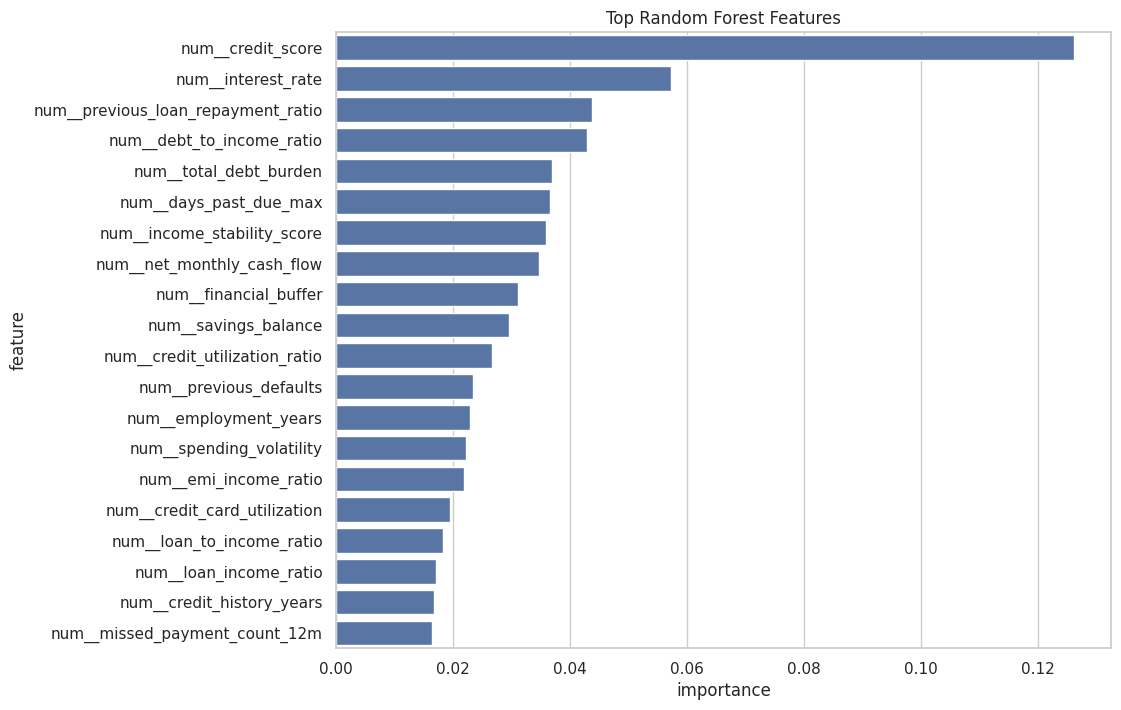

In [33]:
plt.figure(figsize=(10, 8))
sns.barplot(data=importance.head(20), x="importance", y="feature")
plt.title("Top Random Forest Features")
plt.show()


## 14. Save Models

In [34]:
joblib.dump(default_model, "default_model.pkl")
joblib.dump(isolation_forest, "anomaly_model.pkl")
joblib.dump(anomaly_preprocessor, "anomaly_preprocessor.pkl")

print("Saved:")
print(" - default_model.pkl")
print(" - anomaly_model.pkl")
print(" - anomaly_preprocessor.pkl")


Saved:
 - default_model.pkl
 - anomaly_model.pkl
 - anomaly_preprocessor.pkl


## 15. Final Prediction Function

In [35]:
def get_risk_category(probability):
    if probability < 0.20:
        return "Low Risk"
    elif probability < 0.50:
        return "Medium Risk"
    elif probability < 0.75:
        return "High Risk"
    return "Critical Risk"


def align_features(data, expected_features):
    aligned = data.copy()

    for col in expected_features:
        if col not in aligned.columns:
            aligned[col] = np.nan

    return aligned[list(expected_features)]


In [36]:
def predict_loan_risk(new_borrower):
    if isinstance(new_borrower, dict):
        input_df = pd.DataFrame([new_borrower])
    elif isinstance(new_borrower, pd.DataFrame):
        input_df = new_borrower.copy()
    else:
        raise TypeError("Input must be a dictionary or pandas DataFrame.")

    # Same feature engineering used during training
    engineered = engineer_features(input_df)

    # -----------------------------
    # TASK 1: DEFAULT PREDICTION
    # -----------------------------
    default_input = engineered.drop(
        columns=[c for c in LEAKAGE_COLUMNS if c in engineered.columns],
        errors="ignore"
    )

    default_input = align_features(
        default_input,
        default_model.feature_names_in_
    )

    default_probability = float(
        default_model.predict_proba(default_input)[0, 1]
    )

    predicted_default = int(default_probability >= 0.50)
    risk_category = get_risk_category(default_probability)

    # -----------------------------
    # TASK 2: ANOMALY DETECTION
    # -----------------------------
    anomaly_input = engineered.drop(
        columns=[c for c in ANOMALY_EXCLUDE if c in engineered.columns],
        errors="ignore"
    )

    anomaly_input = align_features(
        anomaly_input,
        anomaly_preprocessor.feature_names_in_
    )

    anomaly_processed = anomaly_preprocessor.transform(anomaly_input)

    raw_anomaly = isolation_forest.predict(anomaly_processed)[0]
    anomaly_score = float(
        isolation_forest.decision_function(anomaly_processed)[0]
    )

    return {
        "default_probability": round(default_probability, 4),
        "predicted_default": predicted_default,
        "risk_category": risk_category,
        "anomaly_detected": bool(raw_anomaly == -1),
        "anomaly_score": round(anomaly_score, 4)
    }


## 16. Final New-Borrower Test

In [37]:
sample_borrower = {
    "age": 29,
    "gender": "Female",
    "marital_status": "Single",
    "dependents": 0,
    "education_level": "Bachelor",
    "employment_type": "Salaried",
    "employment_years": 4,
    "residence_type": "Owned",
    "city_tier": "1",
    "annual_income": 600000,
    "monthly_income": 50000,
    "monthly_expenses": 28000,
    "existing_loan_count": 1,
    "existing_loan_amount": 100000,
    "monthly_existing_emi": 5000,
    "credit_card_count": 2,
    "credit_card_utilization": 0.35,
    "savings_balance": 150000,
    "investment_balance": 100000,
    "debt_to_income_ratio": 0.30,
    "net_monthly_cash_flow": 17000,
    "credit_score": 720,
    "credit_history_years": 6,
    "previous_loan_count": 2,
    "previous_defaults": 0,
    "previous_loan_repayment_ratio": 0.98,
    "missed_payment_count_12m": 0,
    "days_past_due_max": 0,
    "recent_credit_inquiries": 1,
    "credit_utilization_ratio": 0.35,
    "loan_type": "Personal",
    "loan_amount": 250000,
    "loan_term_months": 36,
    "interest_rate": 11.5,
    "monthly_emi": 8250,
    "loan_to_income_ratio": 0.42,
    "collateral_value": 0,
    "collateral_type": "None",
    "application_channel": "Online",
    "loan_purpose": "Education",
    "account_age_months": 72,
    "avg_monthly_transaction_count": 45,
    "avg_monthly_transaction_value": 75000,
    "income_stability_score": 0.85,
    "spending_volatility": 0.20,
    "cash_withdrawal_frequency": 4,
    "digital_payment_ratio": 0.75,
    "salary_delay_days_avg": 0
}

result = predict_loan_risk(sample_borrower)

print("=" * 50)
print("             LOAN RISK ASSESSMENT")
print("=" * 50)
print(f"Default Probability : {result['default_probability']:.2%}")
print(f"Predicted Default   : {result['predicted_default']}")
print(f"Risk Category       : {result['risk_category']}")
print(f"Anomaly Detected    : {result['anomaly_detected']}")
print(f"Anomaly Score       : {result['anomaly_score']}")
print("=" * 50)


             LOAN RISK ASSESSMENT
Default Probability : 33.96%
Predicted Default   : 0
Risk Category       : Medium Risk
Anomaly Detected    : False
Anomaly Score       : 0.0096


## 17. Optional: Test Three Profiles

In [38]:
test_borrowers = {
    "Stable Borrower": {
        **sample_borrower,
        "credit_score": 800,
        "previous_defaults": 0,
        "missed_payment_count_12m": 0,
        "debt_to_income_ratio": 0.20
    },
    "High Risk Borrower": {
        **sample_borrower,
        "annual_income": 250000,
        "monthly_income": 20833,
        "credit_score": 520,
        "previous_defaults": 3,
        "missed_payment_count_12m": 6,
        "debt_to_income_ratio": 0.85,
        "loan_amount": 500000
    },
    "Unusual Borrower": {
        **sample_borrower,
        "annual_income": 5000000,
        "monthly_income": 416667,
        "credit_score": 300,
        "existing_loan_count": 15,
        "monthly_existing_emi": 150000,
        "monthly_emi": 200000
    }
}

for name, borrower in test_borrowers.items():
    print("\n" + name)
    print("-" * 40)
    print(predict_loan_risk(borrower))



Stable Borrower
----------------------------------------
{'default_probability': 0.3182, 'predicted_default': 0, 'risk_category': 'Medium Risk', 'anomaly_detected': False, 'anomaly_score': 0.0075}

High Risk Borrower
----------------------------------------
{'default_probability': 0.4546, 'predicted_default': 0, 'risk_category': 'Medium Risk', 'anomaly_detected': True, 'anomaly_score': -0.0129}

Unusual Borrower
----------------------------------------
{'default_probability': 0.3856, 'predicted_default': 0, 'risk_category': 'Medium Risk', 'anomaly_detected': True, 'anomaly_score': -0.0287}
